In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.io import read_image
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [2]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])
train_dataset=datasets.ImageFolder(
    root="./data/seg_train/seg_train",
    transform=train_transform,
)

test_dataset=datasets.ImageFolder(
    root="./data/seg_test/seg_test",
    transform=test_transform,
)
val_dataset=datasets.ImageFolder(
    root="./data/seg_val/seg_val",
    transform=test_transform,
)
print(test_dataset.class_to_idx)
print(f"test: {len(test_dataset)}, \n train: {len(train_dataset)} \n val: {len(val_dataset)}")



{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
test: 3000, 
 train: 10680 
 val: 3354


In [3]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)
val_loader=DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.5179958].


shape= torch.Size([3, 224, 224])


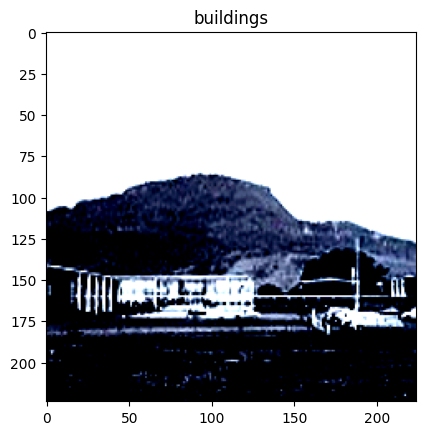

In [4]:
image,label=train_dataset[0]
print("shape=",image.shape)
plt.imshow(image.permute(1,2,0))
plt.title(train_dataset.classes[label])
plt.show()

In [5]:
device=torch.device("cuda")
model=models.resnet18(weights="DEFAULT")
for params in model.parameters():
    params.requires_grad= False

model.fc=nn.Linear(model.fc.in_features, 6)

for params in model.layer4.parameters():
    params.requires_grad=True
criteration=nn.CrossEntropyLoss()
model.to(device)
optimizer=optim.Adam([
  {  "params": model.layer4.parameters(),
    "lr": 0.0001},
  {  "params": model.fc.parameters(),
    "lr": 0.001}
])

In [6]:
epochs=10
for epoch in range(epochs):
    model.train()
    running_loss=0
    average_loss=0
    for images, labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        prediction=model(images)
        loss=criteration(prediction, labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    average_loss=running_loss/len(train_loader)
    model.eval()
    with torch.no_grad():
        accuracy=0
        correct=0
        total=0
        for images, labels in val_loader:
            images=images.to(device)
            labels=labels.to(device)
            prediction=model(images)
            predicted_class=torch.argmax(prediction, dim=1)
            total+=labels.size(0)
            correct += (predicted_class == labels).sum().item()
        accuracy = 100 * correct / total
    print(f"epoch: {epoch+1}/{epochs} | loss: {average_loss}  | validation accuracy: {accuracy}")

epoch: 1/10 | loss: 0.31072030621329827  | validation accuracy: 92.93381037567084
epoch: 2/10 | loss: 0.16139482287968882  | validation accuracy: 93.47048300536673
epoch: 3/10 | loss: 0.10588300825252817  | validation accuracy: 93.0530709600477
epoch: 4/10 | loss: 0.06521021275332164  | validation accuracy: 92.81454979129397
epoch: 5/10 | loss: 0.05400984284111081  | validation accuracy: 93.20214669051879
epoch: 6/10 | loss: 0.04031586039375774  | validation accuracy: 93.53011329755516
epoch: 7/10 | loss: 0.036870044551914456  | validation accuracy: 91.3536076326774
epoch: 8/10 | loss: 0.03844128512849886  | validation accuracy: 91.9200954084675
epoch: 9/10 | loss: 0.028048764576791774  | validation accuracy: 92.69528920691711
epoch: 10/10 | loss: 0.02546370563611495  | validation accuracy: 93.73881932021467


test loss: 0.34511438504407915 | accuracy: 92.60000000000001%


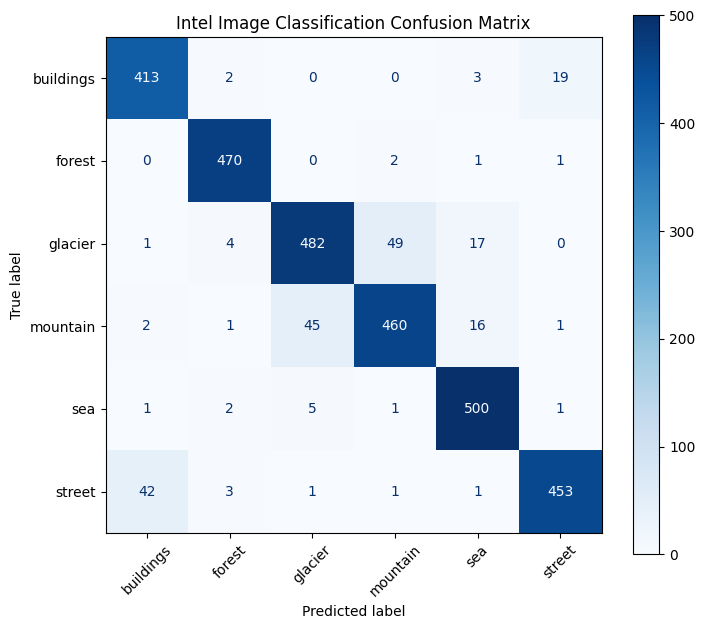

Per Class Accuracy
buildings   : 94.51%
forest      : 99.16%
glacier     : 87.16%
mountain    : 87.62%
sea         : 98.04%
street      : 90.42%


In [7]:


model.eval()
with torch.no_grad():
    train_loss=0
    correct=0
    total=0
    all_preds,all_labels=[],[]
    for images, labels in test_loader:
        images,labels=images.to(device), labels.to(device)
        prediction=model(images)
        total+=labels.size(0)
        predicted_class=torch.argmax(prediction, dim=1)
        correct+=(predicted_class==labels).sum().item()
        loss=criteration(prediction, labels)
        train_loss+=loss.item()
        all_preds.extend(predicted_class.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    total_loss=train_loss/len(test_loader)
    accuracy=100*(correct/total)
    print(f"test loss: {total_loss} | accuracy: {accuracy}%")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Intel Image Classification Confusion Matrix")
plt.show()
print("Per Class Accuracy")
for i, class_name in enumerate(train_dataset.classes):
    total_class = cm[i].sum()
    correct_class = cm[i, i]
    class_accuracy = 100 * correct_class / total_class if total_class > 0 else 0
    print(f"{class_name:<12}: {class_accuracy:.2f}%")